In [1]:
 !git config --global user.email "imen.ben.saad@essai.ucar.tn"

In [2]:
 !git config --global user.name "imen-spark"

In [4]:
!mkdir -p irb-credit-scoring-pd-scorecard/notebooks
!mkdir -p irb-credit-scoring-pd-scorecard/results/figures
!mkdir -p irb-credit-scoring-pd-scorecard/results/tables

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTENC
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import LabelEncoder
from scipy.stats import chi2_contingency
from google.colab import files
import os

In [2]:

# Define the file name
file_name = "base_SNI.xlsx"

# Check if the file exists, if not, prompt the user to upload it
if not os.path.exists(file_name):
    print(f"The file '{file_name}' was not found. Please upload it.")
    uploaded = files.upload()
    if file_name not in uploaded:
        raise FileNotFoundError(f"The file '{file_name}' was not uploaded.")

df = pd.read_excel(file_name)

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5752 entries, 0 to 5751
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id_tiers                   5752 non-null   object        
 1   code_client                5752 non-null   int64         
 2   CRD                        5752 non-null   float64       
 3   PNU                        5752 non-null   float64       
 4   nb_pret                    5752 non-null   int64         
 5   Maturite                   5752 non-null   int64         
 6   Garantie_max               5752 non-null   float64       
 7   flag_lombard_decouvert     5752 non-null   int64         
 8   DPD 12M                    5752 non-null   int64         
 9   Pays de domiciliation      3999 non-null   object        
 10  Etat civil                 3999 non-null   object        
 11  Nationalité                3999 non-null   object        
 12  Profes

In [4]:
print("TYPES OF VARIABLES")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nNumeric Variables ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical Variables ({len(categorical_cols)}): {categorical_cols}")

TYPES OF VARIABLES

Numeric Variables (15): ['code_client', 'CRD', 'PNU', 'nb_pret', 'Maturite', 'Garantie_max', 'flag_lombard_decouvert', 'DPD 12M', 'Age_relation', 'Solde_moyen', 'Revenus_mensuels', 'Solde_arrete', 'Engagement', 'CRD/gar', 'CRD/eng']
Categorical Variables (12): ['id_tiers', 'Pays de domiciliation', 'Etat civil', 'Nationalité', 'Profession', 'Segmentation commercilale', 'Type de revenu', 'Catégorie sociale', 'Code tribunal', 'Code localité', 'Interdiction cheque', 'Segment']


In [5]:
duplicated_rows = df[df.duplicated(keep=False)]

print(f"\nNumber of duplicated rows: {len(duplicated_rows)}")
print(f"Percentage: {len(duplicated_rows)/len(df)*100:.2f}%\n")

# Display duplicated rows
print(duplicated_rows)


Number of duplicated rows: 50
Percentage: 0.87%

        id_tiers  code_client          CRD          PNU  nb_pret  Maturite  \
4     10261_2018        10261   1277030.69         0.00        1        18   
5     10261_2018        10261   1277030.69         0.00        1        18   
6     10261_2019        10261   1226293.50         0.00        1        17   
7     10261_2019        10261   1226293.50         0.00        1        17   
8     10261_2020        10261   1172463.80         0.00        1        16   
9     10261_2020        10261   1172463.80         0.00        1        16   
10    10261_2021        10261   1113645.81         0.00        1        15   
11    10261_2021        10261   1113645.81         0.00        1        15   
12    10277_2018        10277         0.00    237317.56        1       -58   
13    10277_2018        10277         0.00    237317.56        1       -58   
14    10277_2019        10277         0.00    169879.86        1       -59   
15    10277_20

In [6]:
print("Deleting duplicates")

df = df.drop_duplicates()
print(f"New dimensions: {df.shape[0]} rows, {df.shape[1]} columns")

Deleting duplicates
New dimensions: 5725 rows, 29 columns


In [7]:
print("CATEGORICAL VARIABLES")
for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} categories")
    print(df[col].value_counts().head())

CATEGORICAL VARIABLES

id_tiers: 5725 categories
id_tiers
963_2021      1
10231_2018    1
10231_2019    1
10231_2020    1
10231_2021    1
Name: count, dtype: int64

Pays de domiciliation: 14 categories
Pays de domiciliation
Morocco                 3866
France                    47
United Arab Emirates      15
United States             12
United Kingdom            10
Name: count, dtype: int64

Etat civil: 6 categories
Etat civil
Marié          2743
Célibataire    1094
Divorcé         115
Concubinage      15
Veuf              8
Name: count, dtype: int64

Nationalité: 14 categories
Nationalité
Morocco    3837
France       75
Tunisia      17
Algeria      13
Italy        10
Name: count, dtype: int64

Profession: 353 categories
Profession
CADRE                42
SALARIE              25
DIRECTEUR            22
MEDECIN              22
CHEF D'ENTREPRISE    21
Name: count, dtype: int64

Segmentation commercilale: 16 categories
Segmentation commercilale
Indéterminé (S0)                           

In [8]:
df.to_excel("base_without_duplicates.xlsx", index=False)
print("\n File saved: base_without_duplicates.xlsx")


 File saved: base_without_duplicates.xlsx


In [9]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_data_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing_Count': missing_values.values,
    'Percentage': missing_percentage.values
})
missing_data_df = missing_data_df[missing_data_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data_df) > 0:
    print(f"\n⚠ Total missing values: {missing_values.sum()}")
    print(f"\n{len(missing_data_df)} columns with missing values:\n")
    print(missing_data_df.to_string(index=False))

    print("\n--- DETAILED ANALYSIS ---")
    for _, row in missing_data_df.iterrows():
        col = row['Column']
        print(f"\n{col}: {row['Missing_Count']} missing ({row['Percentage']:.1f}%)")
        print(f"  Rows with values: {df[col].notna().sum()}")
        if df[col].dtype == 'object':
            print(f"  Present values: {df[col].value_counts().head(3).to_dict()}")
else:
    print("\n✓ No missing values detected!")


⚠ Total missing values: 33619

17 columns with missing values:

                   Column  Missing_Count  Percentage
      Interdiction cheque           5578   97.432314
            Code tribunal           5092   88.943231
               Profession           4577   79.947598
         Revenus_mensuels           2183   38.131004
           Type de revenu           1963   34.288210
            Code localité           1805   31.528384
        Catégorie sociale           1771   30.934498
    Pays de domiciliation           1749   30.550218
Segmentation commercilale           1749   30.550218
              Nationalité           1749   30.550218
               Etat civil           1749   30.550218
           Date_naissance           1749   30.550218
              Solde_moyen           1529   26.707424
             Solde_arrete            302    5.275109
                  Segment             64    1.117904
               Engagement              5    0.087336
                  CRD/eng         

In [10]:
print("NUMERIC VARIABLES ANALYSIS")
for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  Min: {df[col].min()}, Max: {df[col].max()}, Mean: {df[col].mean():.2f}")

    # Inappropriate negative values
    if any(x in col.lower() for x in ['age', 'montant', 'revenu', 'anciennete']):
        negative_count = (df[col] < 0).sum()
        if negative_count > 0:
            print(f"  ⚠ {negative_count} negative values (inconsistent)")

NUMERIC VARIABLES ANALYSIS

code_client:
  Min: 390, Max: 83408, Mean: 45301.87

CRD:
  Min: 0.0, Max: 106000000.0, Mean: 1496705.78

PNU:
  Min: 0.0, Max: 76982378.6, Mean: 171532.68

nb_pret:
  Min: 1, Max: 13, Mean: 1.24

Maturite:
  Min: -61, Max: 25, Mean: 4.32

Garantie_max:
  Min: 0.0, Max: 215783544.36, Mean: 1487694.87

flag_lombard_decouvert:
  Min: 0, Max: 4, Mean: 0.21

DPD 12M:
  Min: 0, Max: 2052, Mean: 13.22

Age_relation:
  Min: 0, Max: 311, Mean: 46.12

Solde_moyen:
  Min: -3043288.18, Max: 8215673.03, Mean: 74974.08

Revenus_mensuels:
  Min: 0.0, Max: 308896.68, Mean: 36048.09

Solde_arrete:
  Min: -35157500.27902, Max: 28539753.15, Mean: 84338.91

Engagement:
  Min: 8.615, Max: 106000000.0, Mean: 1659906.98

CRD/gar:
  Min: 0.0, Max: 201.498556, Mean: 1.01

CRD/eng:
  Min: 0.0, Max: 4.81770207810168, Mean: 0.86


In [11]:
print("MISSING VALUE HANDLING")

df['Ban_Flag'] = df['Interdiction cheque'].notna().astype(int)
print("✓ Ban_Flag created (1 = has a ban)")

df['Profession'] = df['Profession'].fillna('Not specified')
print("✓ Profession: 'Not specified' for missing values")

df['Missing_Income_Flag'] = df['Revenus_mensuels'].isnull().astype(int)

if 'Segment' in df.columns:
    df['Revenus_mensuels'] = df.groupby('Segment')['Revenus_mensuels'].transform(
        lambda x: x.fillna(x.median())
    )
else:
    df['Revenus_mensuels'] = df['Revenus_mensuels'].fillna(df['Revenus_mensuels'].median())

print("✓ Monthly_Income: imputed by segment median + flag created")

cols_30pct = ['Type de revenu', 'Code localité', 'Catégorie sociale',
                  'Pays de domiciliation', 'Segmentation commercilale',
                  'Nationalité', 'Etat civil', 'Date_naissance']

missing_rows_30 = df[cols_30pct].isnull().all(axis=1).sum()
print(f"\nRows with ALL these variables missing: {missing_rows_30}")

df['Type de revenu'] = df['Type de revenu'].fillna('Unknown')
df['Code localité'] = df['Code localité'].fillna(df['Code localité'].mode()[0] if not df['Code localité'].mode().empty else 'Unknown')
df['Catégorie sociale'] = df['Catégorie sociale'].fillna('Not specified')
df['Pays de domiciliation'] = df['Pays de domiciliation'].fillna('Morocco')
df['Segmentation commercilale'] = df['Segmentation commercilale'].fillna('Undetermined (S0)')
df['Nationalité'] = df['Nationalité'].fillna('Morocco')
df['Etat civil'] = df['Etat civil'].fillna('Unknown')

print("✓ Categorical variables 30%: intelligently imputed")

from datetime import datetime

if df['Date_naissance'].notna().sum() > 0:
    df['Age'] = (datetime.now() - pd.to_datetime(df['Date_naissance'], errors='coerce')).dt.days / 365.25
    df['Age'] = df['Age'].fillna(df['Age'].median())
    print("✓ Age calculated and imputed by median")

if 'Segment' in df.columns:
    df['Solde_moyen'] = df.groupby('Segment')['Solde_moyen'].transform(
        lambda x: x.fillna(x.median())
    )
else:
    df['Solde_moyen'] = df['Solde_moyen'].fillna(df['Solde_moyen'].median())

print("✓ Average_Balance: imputed by segment median")

df['Solde_arrete'] = df['Solde_arrete'].fillna(df['Solde_moyen'])
print("✓ Stopped_Balance: imputed by Average_Balance")

df['Segment'] = df['Segment'].fillna(df['Segment'].mode()[0])
print("✓ Segment: imputed by mode (Retail BRONZE)")

df = df.dropna(subset=['Engagement', 'CRD/eng'])
print("✓ 5 rows with missing Engagement/CRD/eng removed")

df = df.drop(['Code tribunal', 'Interdiction cheque', 'Date_naissance'], axis=1)
print("✓ Useless columns removed (Code tribunal, Interdiction cheque, Date_naissance)")

median_solde = df['Solde_moyen'].median()
df['Solde_moyen'] = df['Solde_moyen'].fillna(median_solde)
print(f"✓ Average_Balance: 67 values imputed by median ({median_solde:.2f})")

median_revenus = df['Revenus_mensuels'].median()
df['Revenus_mensuels'] = df['Revenus_mensuels'].fillna(median_revenus)
print(f"✓ Monthly_Income: 67 values imputed by median ({median_revenus:.2f})")

df['Solde_arrete'] = df['Solde_arrete'].fillna(df['Solde_moyen'])
print("✓ Stopped_Balance: 3 values imputed")

missing_final = df.isnull().sum().sum()
print(f"\n Remaining missing values: {missing_final}")
print(f" Final rows: {len(df)}")
print(f" Final columns: {len(df.columns)}")

if missing_final == 0:
    print("\n 100% COMPLETE BASE!")

df.to_excel("final_complete_base.xlsx", index=False)

MISSING VALUE HANDLING
✓ Ban_Flag created (1 = has a ban)
✓ Profession: 'Not specified' for missing values
✓ Monthly_Income: imputed by segment median + flag created

Rows with ALL these variables missing: 1749
✓ Categorical variables 30%: intelligently imputed
✓ Age calculated and imputed by median
✓ Average_Balance: imputed by segment median
✓ Stopped_Balance: imputed by Average_Balance
✓ Segment: imputed by mode (Retail BRONZE)
✓ 5 rows with missing Engagement/CRD/eng removed
✓ Useless columns removed (Code tribunal, Interdiction cheque, Date_naissance)
✓ Average_Balance: 67 values imputed by median (16166.46)
✓ Monthly_Income: 67 values imputed by median (27000.00)
✓ Stopped_Balance: 3 values imputed

 Remaining missing values: 0
 Final rows: 5720
 Final columns: 29

 100% COMPLETE BASE!


In [12]:
print("CREATION OF THE TARGET VARIABLE 'default_flag'")

df['default_flag'] = (df['DPD 12M'] > 90).astype(int)

print(f"✓ default_flag created (1 = default if DPD > 90 days)")
print(f"\n Distribution default_flag:")
print(df['default_flag'].value_counts())
print(f"\nProportion:")
print(df['default_flag'].value_counts(normalize=True)*100)

CREATION OF THE TARGET VARIABLE 'default_flag'
✓ default_flag created (1 = default if DPD > 90 days)

 Distribution default_flag:
default_flag
0    5604
1     116
Name: count, dtype: int64

Proportion:
default_flag
0    97.972028
1     2.027972
Name: proportion, dtype: float64


In [13]:
excluded_variables = [
    'DPD 12M',
    'id_tiers',
    'code_client',
    'date OBSERVATION'
]

print(f"Variables to exclude: {excluded_variables}")

df_model = df.drop(excluded_variables, axis=1)

Variables to exclude: ['DPD 12M', 'id_tiers', 'code_client', 'date OBSERVATION']


In [14]:
print("VARIABLE SELECTION (re-run for dependency)")

def calculate_iv(df, feature, target):
    """Calculates Information Value for a variable"""
    lst = []
    df_temp = df[[feature, target]].copy()

    if df_temp[feature].dtype in ['int64', 'float64']:
        df_temp[feature] = pd.qcut(df_temp[feature], q=10, duplicates='drop')

    for val in df_temp[feature].unique():
        good = df_temp[(df_temp[feature] == val) & (df_temp[target] == 0)].shape[0]
        bad = df_temp[(df_temp[feature] == val) & (df_temp[target] == 1)].shape[0]

        total_good = df_temp[df_temp[target] == 0].shape[0]
        total_bad = df_temp[df_temp[target] == 1].shape[0]

        pct_good = good / total_good if total_good > 0 else 0.0001
        pct_bad = bad / total_bad if total_bad > 0 else 0.0001

        woe = np.log(pct_good / pct_bad) if pct_bad > 0 else 0
        iv = (pct_good - pct_bad) * woe

        lst.append({'Variable': feature, 'WOE': woe, 'IV': iv})

    return sum([x['IV'] for x in lst])

iv_results = []
for col in df_model.drop('default_flag', axis=1).columns:
    try:
        iv_value = calculate_iv(df_model, col, 'default_flag')
        iv_results.append({'Variable': col, 'IV': iv_value})
    except:
        iv_results.append({'Variable': col, 'IV': 0})

iv_df = pd.DataFrame(iv_results).sort_values('IV', ascending=False)

selected_variables_iv = iv_df[iv_df['IV'] >= 0.02]['Variable'].tolist()

def cramers_v(x, y):
    """Calculates Cramer's V between two variables"""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

variables_to_remove = []
cat_cols = df_model[selected_variables_iv].select_dtypes(include=['object']).columns.tolist()
if len(cat_cols) > 1:
    cramer_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
    for col1 in cat_cols:
        for col2 in cat_cols:
            if col1 == col2:
                cramer_matrix.loc[col1, col2] = 1.0
            else:
                cramer_matrix.loc[col1, col2] = cramers_v(df_model[col1], df_model[col2])
    for i in range(len(cramer_matrix.columns)):
        for j in range(i+1, len(cramer_matrix.columns)):
            v_value = float(cramer_matrix.iloc[i, j])
            if v_value > 0.3:
                col1 = cramer_matrix.columns[i]
                col2 = cramer_matrix.columns[j]
                iv1 = iv_df[iv_df['Variable'] == col1]['IV'].values[0]
                iv2 = iv_df[iv_df['Variable'] == col2]['IV'].values[0]
                if iv1 < iv2:
                    variables_to_remove.append(col1)
                else:
                    variables_to_remove.append(col2)
    variables_to_remove = list(set(variables_to_remove))

num_cols = df_model[selected_variables_iv].select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) > 1:
    corr_matrix = df_model[num_cols].corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_value = corr_matrix.iloc[i, j]
            if abs(corr_value) > 0.8:
                col1 = corr_matrix.columns[i]
                col2 = corr_matrix.columns[j]
                iv1 = iv_df[iv_df['Variable'] == col1]['IV'].values[0]
                iv2 = iv_df[iv_df['Variable'] == col2]['IV'].values[0]
                if iv1 < iv2:
                    variables_to_remove.append(col1)
                else:
                    variables_to_remove.append(col2)
variables_to_remove = list(set(variables_to_remove))

final_variables = [v for v in selected_variables_iv if v not in variables_to_remove]


print(" DATASET SPLIT INTO TRAINING AND TEST SETS")

X = df_model[final_variables]
y = df_model['default_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"\n✓ Training set: {len(X_train)} rows (70%)")
print(f"✓ Test set: {len(X_test)} rows (30%)")

print(f"\n Distribution default_flag in TRAIN:")
print(y_train.value_counts())
print(f"Proportion: {y_train.value_counts(normalize=True)*100}")

print(f"\n Distribution default_flag in TEST:")
print(y_test.value_counts())
print(f"Proportion: {y_test.value_counts(normalize=True)*100}")

VARIABLE SELECTION (re-run for dependency)


/tmp/ipykernel_901/356793005.py:21: RuntimeWarning: divide by zero encountered in log
  woe = np.log(pct_good / pct_bad) if pct_bad > 0 else 0
/tmp/ipykernel_901/356793005.py:21: RuntimeWarning: divide by zero encountered in log
  woe = np.log(pct_good / pct_bad) if pct_bad > 0 else 0


 DATASET SPLIT INTO TRAINING AND TEST SETS

✓ Training set: 4004 rows (70%)
✓ Test set: 1716 rows (30%)

 Distribution default_flag in TRAIN:
default_flag
0    3923
1      81
Name: count, dtype: int64
Proportion: default_flag
0    97.977023
1     2.022977
Name: proportion, dtype: float64

 Distribution default_flag in TEST:
default_flag
0    1681
1      35
Name: count, dtype: int64
Proportion: default_flag
0    97.960373
1     2.039627
Name: proportion, dtype: float64


VARIABLE SELECTION

--- Information Value Calculation ---


/tmp/ipykernel_901/3147828228.py:22: RuntimeWarning: divide by zero encountered in log
  woe = np.log(pct_good / pct_bad) if pct_bad > 0 else 0
/tmp/ipykernel_901/3147828228.py:22: RuntimeWarning: divide by zero encountered in log
  woe = np.log(pct_good / pct_bad) if pct_bad > 0 else 0



INFORMATION VALUE PER VARIABLE:
Profession                          IV =      inf   Suspect predictive power
Segmentation commercilale           IV =      inf   Suspect predictive power
Solde_arrete                        IV =   1.2765   Suspect predictive power
Solde_moyen                         IV =   0.6055   Suspect predictive power
CRD/eng                             IV =   0.5056   Suspect predictive power
Type de revenu                      IV =   0.3942  ✓✓ Strong predictive power
Catégorie sociale                   IV =   0.3938  ✓✓ Strong predictive power
Age                                 IV =   0.3433  ✓✓ Strong predictive power
Maturite                            IV =   0.3433  ✓✓ Strong predictive power
Age_relation                        IV =   0.3345  ✓✓ Strong predictive power
Segment                             IV =   0.2352  ✓ Medium predictive power
Code localité                       IV =   0.2116  ✓ Medium predictive power
Garantie_max                        IV

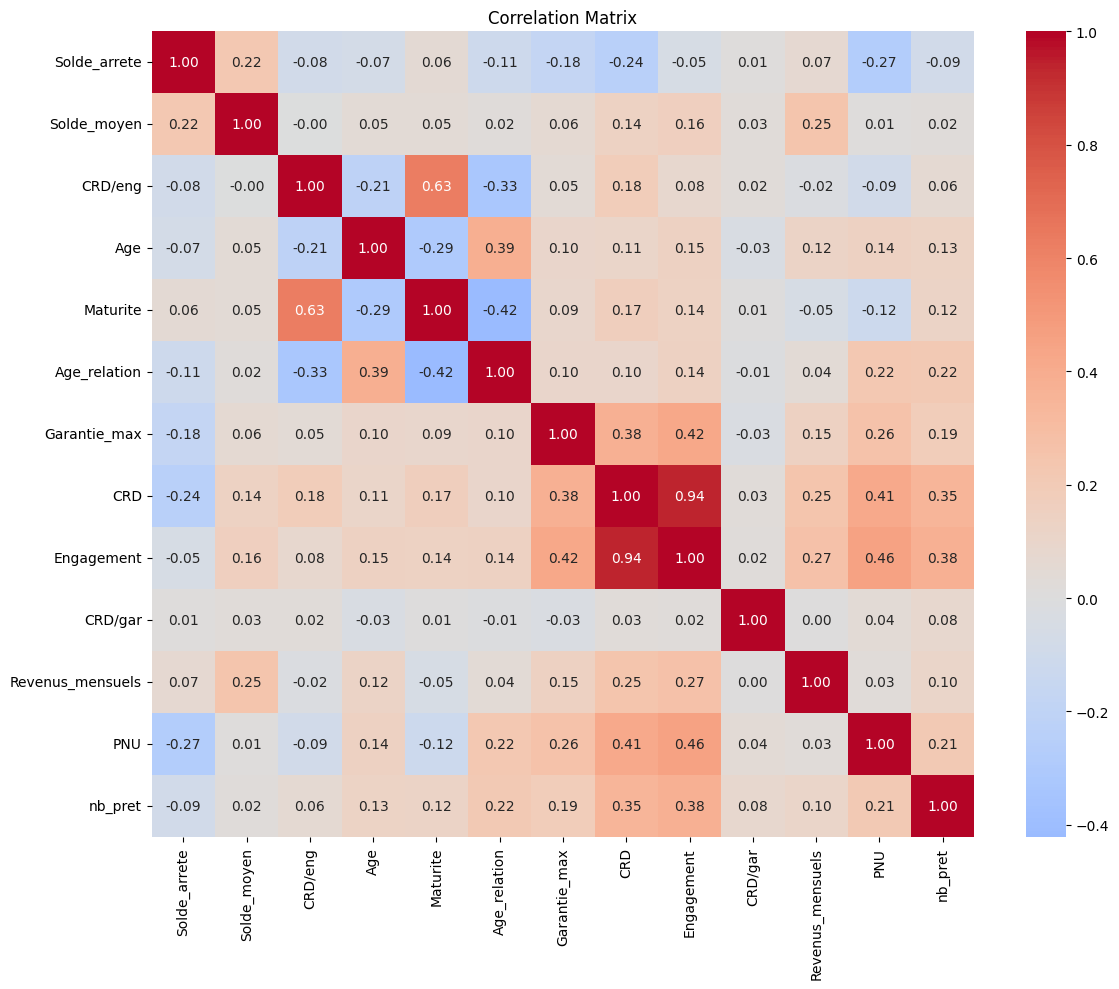

SELECTION SUMMARY
Initial variables: 25
After IV filter (≥ 0.02): 21
Variables removed (dependence): 8
Final retained variables: 13

 Selected variables:
['Profession', 'Solde_arrete', 'Solde_moyen', 'CRD/eng', 'Age', 'Maturite', 'Age_relation', 'Garantie_max', 'CRD', 'CRD/gar', 'Revenus_mensuels', 'PNU', 'nb_pret']


In [15]:

print("VARIABLE SELECTION")


def calculate_iv(df, feature, target):
    """Calculates Information Value for a variable"""
    lst = []
    df_temp = df[[feature, target]].copy()

    if df_temp[feature].dtype in ['int64', 'float64']:
        df_temp[feature] = pd.qcut(df_temp[feature], q=10, duplicates='drop')

    for val in df_temp[feature].unique():
        good = df_temp[(df_temp[feature] == val) & (df_temp[target] == 0)].shape[0]
        bad = df_temp[(df_temp[feature] == val) & (df_temp[target] == 1)].shape[0]

        total_good = df_temp[df_temp[target] == 0].shape[0]
        total_bad = df_temp[df_temp[target] == 1].shape[0]

        pct_good = good / total_good if total_good > 0 else 0.0001
        pct_bad = bad / total_bad if total_bad > 0 else 0.0001

        woe = np.log(pct_good / pct_bad) if pct_bad > 0 else 0
        iv = (pct_good - pct_bad) * woe

        lst.append({'Variable': feature, 'WOE': woe, 'IV': iv})

    return sum([x['IV'] for x in lst])

print("\n--- Information Value Calculation ---")
iv_results = []
for col in df_model.drop('default_flag', axis=1).columns:
    try:
        iv_value = calculate_iv(df_model, col, 'default_flag')
        iv_results.append({'Variable': col, 'IV': iv_value})
    except:
        iv_results.append({'Variable': col, 'IV': 0})

iv_df = pd.DataFrame(iv_results).sort_values('IV', ascending=False)

print("\nINFORMATION VALUE PER VARIABLE:")

for _, row in iv_df.iterrows():
    var = row['Variable']
    iv = row['IV']

    if iv < 0.02:
        interpretation = " Not useful for prediction"
    elif iv < 0.1:
        interpretation = " Weak predictive power"
    elif iv < 0.3:
        interpretation = "✓ Medium predictive power"
    elif iv < 0.5:
        interpretation = "✓✓ Strong predictive power"
    else:
        interpretation = " Suspect predictive power"

    print(f"{var:<35} IV = {iv:>8.4f}  {interpretation}")

selected_variables_iv = iv_df[iv_df['IV'] >= 0.02]['Variable'].tolist()
print(f"\n Variables retained after IV (≥ 0.02): {len(selected_variables_iv)}")


print("STUDY OF VARIABLE DEPENDENCE")


def cramers_v(x, y):
    """Calculates Cramer's V between two variables"""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

print("\n--- Cramer's V (categorical variables) ---")
cat_cols = df_model[selected_variables_iv].select_dtypes(include=['object']).columns.tolist()

if len(cat_cols) > 1:
    cramer_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

    for col1 in cat_cols:
        for col2 in cat_cols:
            if col1 == col2:
                cramer_matrix.loc[col1, col2] = 1.0
            else:
                cramer_matrix.loc[col1, col2] = cramers_v(df_model[col1], df_model[col2])

    print("\nPairs of strongly dependent variables (Cramer's V > 0.3):")
    variables_to_remove = []

    for i in range(len(cramer_matrix.columns)):
        for j in range(i+1, len(cramer_matrix.columns)):
            v_value = float(cramer_matrix.iloc[i, j])
            if v_value > 0.3:
                col1 = cramer_matrix.columns[i]
                col2 = cramer_matrix.columns[j]
                print(f"  {col1} <-> {col2} : V = {v_value:.3f}")

                iv1 = iv_df[iv_df['Variable'] == col1]['IV'].values[0]
                iv2 = iv_df[iv_df['Variable'] == col2]['IV'].values[0]

                if iv1 < iv2:
                    variables_to_remove.append(col1)
                    print(f"    → Remove {col1} (lower IV)")
                else:
                    variables_to_remove.append(col2)
                    print(f"    → Remove {col2} (lower IV)")

    variables_to_remove = list(set(variables_to_remove))
else:
    variables_to_remove = []
    print("Not enough categorical variables to calculate Cramer's V")

print("\n--- Correlation Matrix (numerical variables) ---")
num_cols = df_model[selected_variables_iv].select_dtypes(include=[np.number]).columns.tolist()

if len(num_cols) > 1:
    corr_matrix = df_model[num_cols].corr()

    print("\nPairs of strongly correlated variables (|corr| > 0.8):")
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_value = corr_matrix.iloc[i, j]
            if abs(corr_value) > 0.8:
                col1 = corr_matrix.columns[i]
                col2 = corr_matrix.columns[j]
                print(f"  {col1} <-> {col2} : corr = {corr_value:.3f}")

                iv1 = iv_df[iv_df['Variable'] == col1]['IV'].values[0]
                iv2 = iv_df[iv_df['Variable'] == col2]['IV'].values[0]

                if iv1 < iv2:
                    variables_to_remove.append(col1)
                    print(f"    → Remove {col1} (lower IV)")
                else:
                    variables_to_remove.append(col2)
                    print(f"    → Remove {col2} (lower IV)")

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()

variables_to_remove = list(set(variables_to_remove))

final_variables = [v for v in selected_variables_iv if v not in variables_to_remove]


print("SELECTION SUMMARY")

print(f"Initial variables: {len(df_model.columns) - 1}")
print(f"After IV filter (≥ 0.02): {len(selected_variables_iv)}")
print(f"Variables removed (dependence): {len(variables_to_remove)}")
print(f"Final retained variables: {len(final_variables)}")
print(f"\n Selected variables:")
print(final_variables)

In [16]:
print("RESAMPLING WITH SMOTE-NC")


X = df_model[final_variables]
y = df_model['default_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)
print(f"✓ Training set: {len(X_train)} rows (70%)")
print(f"✓ Test set: {len(X_test)} rows (30%)")



print("X_train shape before SMOTE-NC:", X_train.shape)
print("X_train dtypes before SMOTE-NC:\n", X_train.dtypes)

if 'date OBSERVATION' in X_train.columns:

    print("Warning: 'date OBSERVATION' found in X_train, converting it to numeric.")
    X_train['date OBSERVATION'] = pd.to_datetime(X_train['date OBSERVATION']).astype('int64') / 10**9
    X_test['date OBSERVATION'] = pd.to_datetime(X_test['date OBSERVATION']).astype('int64') / 10**9
    print("✓ Date converted to numeric")


# Correctly identify categorical features
categorical_indices = [i for i, col in enumerate(X_train.columns) if X_train[col].dtype == 'object']


print("\n BEFORE SMOTE-NC:")
print(f"Class 0: {(y_train==0).sum()} | Class 1: {(y_train==1).sum()}")

# Apply SMOTENC only if categorical features are identified, otherwise use SMOTE
if len(categorical_indices) > 0:
    print("Using SMOTENC (categorical variables detected).")
    smotenc = SMOTENC(categorical_features=categorical_indices, random_state=42)
    X_train_resampled, y_train_resampled = smotenc.fit_resample(X_train, y_train)
else:
    print("Warning: No categorical variables detected. Using standard SMOTE.")
    from imblearn.over_sampling import SMOTE
    smote_standard = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote_standard.fit_resample(X_train, y_train)


print("\nAFTER SMOTE-NC/SMOTE:")
print(f"Class 0: {(y_train_resampled==0).sum()} | Class 1: {(y_train_resampled==1).sum()}")
print(f"Total: {len(y_train_resampled)} rows")

print("\n DATA READY FOR MODELING")
print(f"   • Selected variables: {len(final_variables)}")
print(f"   • Balanced Train: {len(X_train_resampled)} rows")
print(f"   • Test: {len(X_test)} rows")

RESAMPLING WITH SMOTE-NC
✓ Training set: 4004 rows (70%)
✓ Test set: 1716 rows (30%)
X_train shape before SMOTE-NC: (4004, 13)
X_train dtypes before SMOTE-NC:
 Profession           object
Solde_arrete        float64
Solde_moyen         float64
CRD/eng             float64
Age                 float64
Maturite              int64
Age_relation          int64
Garantie_max        float64
CRD                 float64
CRD/gar             float64
Revenus_mensuels    float64
PNU                 float64
nb_pret               int64
dtype: object

 BEFORE SMOTE-NC:
Class 0: 3923 | Class 1: 81
Using SMOTENC (categorical variables detected).

AFTER SMOTE-NC/SMOTE:
Class 0: 3923 | Class 1: 3923
Total: 7846 rows

 DATA READY FOR MODELING
   • Selected variables: 13
   • Balanced Train: 7846 rows
   • Test: 1716 rows


In [17]:

print("\n--- Saving results to an Excel file ---")

with pd.ExcelWriter("project_SNI_results.xlsx", engine='openpyxl') as writer:

    # Sheet 1: Train and Test Bases
    df_train_export = X_train.copy()
    df_train_export['default_flag'] = y_train.values
    df_train_export['Type'] = 'Train'

    df_test_export = X_test.copy()
    df_test_export['default_flag'] = y_test.values
    df_test_export['Type'] = 'Test'

    df_combined = pd.concat([df_train_export, df_test_export], ignore_index=True)
    df_combined.to_excel(writer, sheet_name='Train_Test_Bases', index=False)

    # Sheet 2: Resampled Train Base
    df_train_resampled = pd.DataFrame(X_train_resampled, columns=X_train.columns)
    df_train_resampled['default_flag'] = y_train_resampled
    df_train_resampled.to_excel(writer, sheet_name='Resampled_Train', index=False)

    # Sheet 3: IV Calculation
    iv_df.to_excel(writer, sheet_name='IV_Calculation', index=False)

    # Sheet 4: Dependence Study
    if len(num_cols) > 1:
        corr_matrix.to_excel(writer, sheet_name='Dependence_Study')
    else:
        pd.DataFrame({'Note': ['No correlation matrix available']}).to_excel(
            writer, sheet_name='Dependence_Study', index=False)

print("✓ All results saved to: project_SNI_results.xlsx")
print("  • Sheet 1: Train_Test_Bases")
print("  • Sheet 2: Resampled_Train")
print("  • Sheet 3: IV_Calculation")
print("  • Sheet 4: Dependence_Study")


--- Saving results to an Excel file ---
✓ All results saved to: project_SNI_results.xlsx
  • Sheet 1: Train_Test_Bases
  • Sheet 2: Resampled_Train
  • Sheet 3: IV_Calculation
  • Sheet 4: Dependence_Study


In [18]:
print("\n--- Data Preparation ---")

# Encode categorical variables

X_train_model = X_train_resampled.copy()
X_test_model = X_test.copy()

for col in X_train_model.columns:
    if X_train_model[col].dtype == 'object':
        le = LabelEncoder()
        combined = pd.concat([X_train_model[col], X_test_model[col]]).astype(str)
        le.fit(combined)
        X_train_model[col] = le.transform(X_train_model[col].astype(str))
        X_test_model[col] = le.transform(X_test_model[col].astype(str))

print("✓ Categorical variables encoded")

# Standardize numerical variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_model)
X_test_scaled = scaler.transform(X_test_model)

print("✓ Variables standardized")


--- Data Preparation ---
✓ Categorical variables encoded
✓ Variables standardized


In [19]:

print("TRAINING THE LOGISTIC REGRESSION MODEL")


logreg = LogisticRegression(
    random_state=42,
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced'
)

logreg.fit(X_train_scaled, y_train_resampled)

print("✓ Model trained")


print("\n--- Model Coefficients ---")
coef_df = pd.DataFrame({
    'Variable': X_train_model.columns,
    'Coefficient': logreg.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print(coef_df.to_string(index=False))

TRAINING THE LOGISTIC REGRESSION MODEL
✓ Model trained

--- Model Coefficients ---
        Variable  Coefficient
     Solde_moyen    -3.987580
    Solde_arrete    -0.774719
    Age_relation     0.504697
         nb_pret    -0.364735
         CRD/eng     0.250362
Revenus_mensuels     0.197416
         CRD/gar    -0.181728
             Age     0.172374
             PNU     0.147311
    Garantie_max    -0.095829
      Profession     0.083008
        Maturite     0.060397
             CRD     0.009685


In [20]:

print("PREDICTIONS")


y_pred_train = logreg.predict(X_train_scaled)
y_pred_test = logreg.predict(X_test_scaled)

y_pred_proba_train = logreg.predict_proba(X_train_scaled)[:, 1]
y_pred_proba_test = logreg.predict_proba(X_test_scaled)[:, 1]

print("✓ Predictions made")

PREDICTIONS
✓ Predictions made


In [21]:

print("PERFORMANCE EVALUATION - TEST SET")


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
print("\n--- Confusion Matrix ---")
print(f"                     Predicted Non-Default  Predicted Default")
print(f"Actual Non-Default        {cm[0,0]:<10}      {cm[0,1]:<10}")
print(f"Actual Default            {cm[1,0]:<10}      {cm[1,1]:<10}")

# Basic Metrics
accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)

print("\n--- Classification Metrics ---")
print(f"Accuracy:               {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision:              {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall (Sensitivity):   {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:               {f1:.4f}")

# AUC and GINI
auc = roc_auc_score(y_test, y_pred_proba_test)
gini = 2 * auc - 1

print("\n--- Banking Metrics (SNI) ---")
print(f"AUC (Area Under Curve): {auc:.4f} ({auc*100:.2f}%)")
print(f"GINI:                   {gini:.4f} ({gini*100:.2f}%)")

# GINI Interpretation
if gini < 0.3:
    interpretation = " Weak discriminating power"
elif gini < 0.5:
    interpretation = "✓ Acceptable discriminating power"
elif gini < 0.7:
    interpretation = "✓✓ Good discriminating power"
else:
    interpretation = "✓✓✓ Excellent discriminating power"

print(f"\nGINI Interpretation: {interpretation}")

PERFORMANCE EVALUATION - TEST SET

--- Confusion Matrix ---
                     Predicted Non-Default  Predicted Default
Actual Non-Default        1283            398       
Actual Default            10              25        

--- Classification Metrics ---
Accuracy:               0.7622 (76.22%)
Precision:              0.0591 (5.91%)
Recall (Sensitivity):   0.7143 (71.43%)
F1-Score:               0.1092

--- Banking Metrics (SNI) ---
AUC (Area Under Curve): 0.7644 (76.44%)
GINI:                   0.5289 (52.89%)

GINI Interpretation: ✓✓ Good discriminating power


In [22]:

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred_test,
                          target_names=['Non-Default', 'Default']))


--- Detailed Classification Report ---
              precision    recall  f1-score   support

 Non-Default       0.99      0.76      0.86      1681
     Default       0.06      0.71      0.11        35

    accuracy                           0.76      1716
   macro avg       0.53      0.74      0.49      1716
weighted avg       0.97      0.76      0.85      1716




--- ROC Curve Plot ---


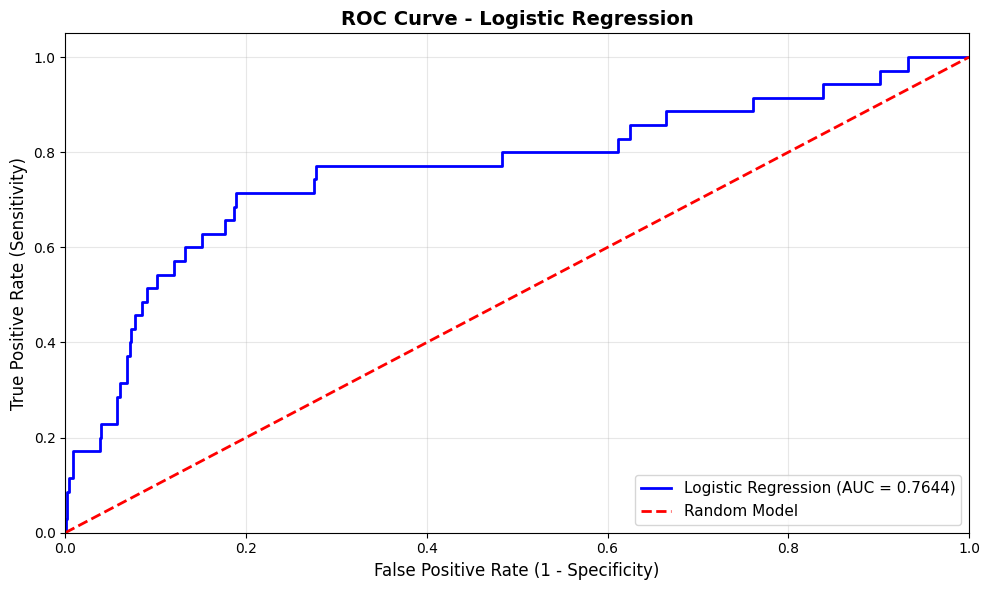

TRAIN vs TEST PERFORMANCE COMPARISON
Metric               TRAIN                TEST                 Difference          
AUC                  0.7989               0.7644               0.0344              
GINI                 0.5977               0.5289               0.0688              
Accuracy             0.7391               0.7622               0.0231              

✓ Acceptable difference between Train and Test → Generalizable model
 MODELING COMPLETE

 PERFORMANCE SUMMARY:
   • GINI: 0.5289 (✓✓ Good discriminating power)
   • AUC: 0.7644
   • Recall (default detection): 0.7143
   • Precision: 0.0591


In [23]:

print("\n--- ROC Curve Plot ---")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_test)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Logistic Regression (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Model')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve - Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


print("TRAIN vs TEST PERFORMANCE COMPARISON")


auc_train = roc_auc_score(y_train_resampled, y_pred_proba_train)
gini_train = 2 * auc_train - 1

print(f"{'Metric':<20} {'TRAIN':<20} {'TEST':<20} {'Difference':<20}")

print(f"{'AUC':<20} {auc_train:<20.4f} {auc:<20.4f} {abs(auc_train-auc):<20.4f}")
print(f"{'GINI':<20} {gini_train:<20.4f} {gini:<20.4f} {abs(gini_train-gini):<20.4f}")
print(f"{'Accuracy':<20} {accuracy_score(y_train_resampled, y_pred_train):<20.4f} {accuracy:<20.4f} {abs(accuracy_score(y_train_resampled, y_pred_train)-accuracy):<20.4f}")

if abs(auc_train - auc) > 0.1:
    print("\n Significant difference between Train and Test → Overfitting risk")
else:
    print("\n✓ Acceptable difference between Train and Test → Generalizable model")


print(" MODELING COMPLETE")

print(f"\n PERFORMANCE SUMMARY:")
print(f"   • GINI: {gini:.4f} ({interpretation})")
print(f"   • AUC: {auc:.4f}")
print(f"   • Recall (default detection): {recall:.4f}")
print(f"   • Precision: {precision:.4f}")

In [24]:
print("FINAL STEP: DEFAULT PROBABILITY PREDICTION & SCORECARD")
print("\n--- Calculation of Default Probabilities (PD) ---")

# Calculate PD for all test clients
pd_test = y_pred_proba_test

df_scores = pd.DataFrame({
    'Default_Probability': pd_test,
    'Actual_Class': y_test.values
})

print(f"✓ Default probabilities calculated for {len(df_scores)} clients")
print(f"\nPD Statistics:")
print(df_scores['Default_Probability'].describe())

FINAL STEP: DEFAULT PROBABILITY PREDICTION & SCORECARD

--- Calculation of Default Probabilities (PD) ---
✓ Default probabilities calculated for 1716 clients

PD Statistics:
count    1.716000e+03
mean     3.908297e-01
std      1.916792e-01
min      3.483870e-41
25%      2.897366e-01
50%      4.267082e-01
75%      4.977449e-01
max      1.000000e+00
Name: Default_Probability, dtype: float64


In [25]:

print("SCORECARD CREATION")



# Score = offset - factor * ln(PD / (1 - PD))
offset = 600
factor = 50 / np.log(2)

def pd_to_score(pd):
    """Converts a default probability to a score"""
    pd = np.clip(pd, 0.0001, 0.9999)  # Avoid extreme values
    odds = pd / (1 - pd)
    score = offset - factor * np.log(odds)
    return score

df_scores['Score'] = df_scores['Default_Probability'].apply(pd_to_score)

print(f"\nScore Statistics:")
print(df_scores['Score'].describe())

SCORECARD CREATION

Score Statistics:
count    1716.000000
mean      657.589816
std       146.277838
min       -64.378405
25%       600.650694
50%       621.301007
75%       664.680622
max      1264.378405
Name: Score, dtype: float64



--- Discretization into Risk Classes ---

SCORECARD BY RISK CLASS:
                PD_Mean  PD_Min  PD_Max  Score_Mean  Score_Min  Score_Max  \
Risk_Class                                                                  
G (Very High)    0.9461  0.8975  0.9876    385.1284   284.1268   443.4866   
F (High)         0.8379  0.8034  0.8795    480.5965   456.6140   498.4681   
E (Elevated)     0.7242  0.6668  0.7907    529.7896   504.1099   549.9470   
D (Medium)       0.5549  0.5005  0.6659    583.9175   550.2599   599.8688   
C (Acceptable)   0.4297  0.3345  0.4997    620.5896   600.0752   649.6316   
B (Low)          0.2773  0.2003  0.3329    669.6566   650.1312   699.8789   
A (Very Low)     0.0862  0.0041  0.1979    801.3642   700.9546   997.0063   

                Num_Defaults  Total_Count  Actual_Default_Rate  
Risk_Class                                                      
G (Very High)              3           16                18.75  
F (High)                   0           14  

/tmp/ipykernel_901/1795081641.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_analysis = df_scores.groupby('Risk_Class').agg({
/tmp/ipykernel_901/1795081641.py:80: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hl_table = df_hl.groupby('decile').agg({


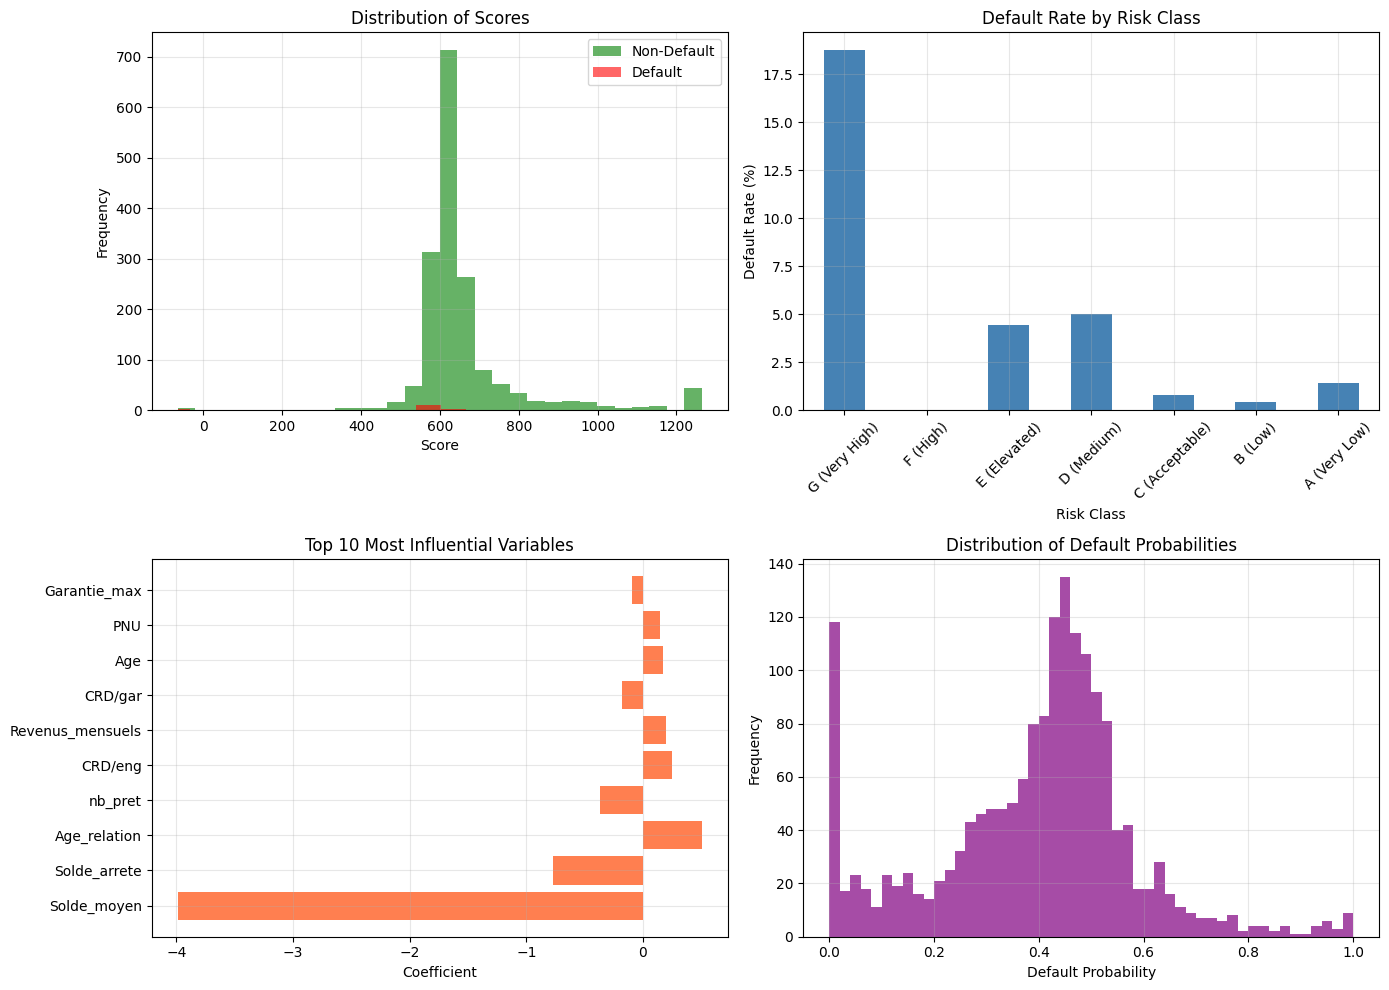

In [26]:
print("\n--- Discretization into Risk Classes ---")


df_scores['Risk_Class'] = pd.cut(
    df_scores['Score'],
    bins=[0, 450, 500, 550, 600, 650, 700, 1000],
    labels=['G (Very High)', 'F (High)', 'E (Elevated)', 'D (Medium)',
            'C (Acceptable)', 'B (Low)', 'A (Very Low)']
)


risk_analysis = df_scores.groupby('Risk_Class').agg({
    'Default_Probability': ['mean', 'min', 'max'],
    'Score': ['mean', 'min', 'max'],
    'Actual_Class': ['sum', 'count']
}).round(4)

risk_analysis.columns = ['PD_Mean', 'PD_Min', 'PD_Max',
                            'Score_Mean', 'Score_Min', 'Score_Max',
                            'Num_Defaults', 'Total_Count']
risk_analysis['Actual_Default_Rate'] = (risk_analysis['Num_Defaults'] /
                                        risk_analysis['Total_Count'] * 100).round(2)

print("\nSCORECARD BY RISK CLASS:")

print(risk_analysis)


print("\n✓ Monotonicity check:")
default_rates = risk_analysis['Actual_Default_Rate'].values
if all(default_rates[i] <= default_rates[i+1] for i in range(len(default_rates)-1)):
    print("    Default rate is increasing → Valid scale")
else:
    print("    Default rate is not perfectly increasing")


print("INTERPRETATION OF COEFFICIENTS")


coef_df = pd.DataFrame({
    'Variable': X_train_model.columns,
    'Coefficient': logreg.coef_[0]
})

coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

print("\nMOST INFLUENTIAL VARIABLES:")

print(f"{'Variable':<35} {'Coefficient':<15} {'Impact':<20}")


for _, row in coef_df.head(10).iterrows():
    var = row['Variable']
    coef = row['Coefficient']

    if coef > 0:
        impact = "↑ Increases risk"
    else:
        impact = "↓ Reduces risk"

    print(f"{var:<35} {coef:>10.4f}     {impact}")

print("\n INTERPRETATION:")
print("• Positive coefficient → Increases default probability")
print("• Negative coefficient → Reduces default probability")
print("• The higher the coefficient (in absolute value), the more influential the variable")


print("SCORECARD MODEL VALIDATION")

# predictive power
from scipy.stats import chi2

def hosmer_lemeshow_test(y_true, y_pred_proba, groups=10):
    """Hosmer-Lemeshow Test"""
    df_hl = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred_proba})
    df_hl['decile'] = pd.qcut(df_hl['y_pred'], q=groups, duplicates='drop')

    hl_table = df_hl.groupby('decile').agg({
        'y_true': ['sum', 'count'],
        'y_pred': 'mean'
    })

    observed_pos = hl_table['y_true']['sum'].values
    total = hl_table['y_true']['count'].values
    expected_pos = hl_table['y_pred']['mean'].values * total

    observed_neg = total - observed_pos
    expected_neg = total - expected_pos

    hl_stat = np.sum((observed_pos - expected_pos)**2 / (expected_pos + 1e-10) +
                     (observed_neg - expected_neg)**2 / (expected_neg + 1e-10))

    p_value = 1 - chi2.cdf(hl_stat, groups - 2)

    return hl_stat, p_value

hl_stat, hl_pvalue = hosmer_lemeshow_test(y_test, y_pred_proba_test)

print("\n--- DISCRIMINATING POWER ---")
print(f"AUC: {auc:.4f}")
if auc > 0.7:
    print(" Excellent discriminating power")
elif auc > 0.6:
    print(" Good discriminating power")
else:
    print(" Weak discriminating power")

print("\n--- PREDICTIVE POWER ---")
print(f"Hosmer-Lemeshow Test:")
print(f"  Statistic: {hl_stat:.4f}")
print(f"  P-value: {hl_pvalue:.4f}")

if hl_pvalue > 0.05:
    print("   Good predictive power (p-value > 0.05)")
elif hl_pvalue > 0.01:
    print("   Acceptable predictive power (0.01 < p-value < 0.05)")
else:
    print("   Weak predictive power (p-value < 0.01)")

# KS Statistic
from scipy.stats import ks_2samp

pd_defaut = df_scores[df_scores['Actual_Class'] == 1]['Default_Probability']
pd_non_defaut = df_scores[df_scores['Actual_Class'] == 0]['Default_Probability']

ks_stat, ks_pvalue = ks_2samp(pd_defaut, pd_non_defaut)

print(f"\nKolmogorov-Smirnov Test:")
print(f"  KS Statistic: {ks_stat:.4f}")
print(f"  P-value: {ks_pvalue:.4f}")

if ks_pvalue > 0.1:
    print("   Excellent stability")
elif ks_pvalue > 0.01:
    print("   Good stability")
else:
    print("   Stability to monitor")



print("FINAL PD SCALE")


pd_scale = risk_analysis[['PD_Mean', 'Score_Mean', 'Actual_Default_Rate', 'Total_Count']].copy()
pd_scale.columns = ['Mean PD (%)', 'Mean Score', 'Actual Default Rate (%)', 'Number of Clients']
pd_scale['Mean PD (%)'] = (pd_scale['Mean PD (%)'] * 100).round(2)

print("\n FINAL SCORE SCALE:")
print(pd_scale)

print("\n  INTERPRETATION:")
print("• Class A (Score > 700) : Very low risk → Excellent clients")
print("• Class B-C (600-700) : Low/acceptable risk → Good clients")
print("• Class D (550-600) : Medium risk → Clients to monitor")
print("• Class E-F (450-550) : High/elevated risk → Precautions needed")
print("• Class G (Score < 450) : Very high risk → Refusal or strict conditions")


print("\n--- Generating visualizations ---")


fig, axes = plt.subplots(2, 2, figsize=(14, 10))


axes[0, 0].hist(df_scores[df_scores['Actual_Class']==0]['Score'],
                bins=30, alpha=0.6, label='Non-Default', color='green')
axes[0, 0].hist(df_scores[df_scores['Actual_Class']==1]['Score'],
                bins=30, alpha=0.6, label='Default', color='red')
axes[0, 0].set_xlabel('Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Scores')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)


risk_analysis['Actual_Default_Rate'].plot(kind='bar', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_xlabel('Risk Class')
axes[0, 1].set_ylabel('Default Rate (%)')
axes[0, 1].set_title('Default Rate by Risk Class')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(alpha=0.3)


coef_df_top = coef_df.head(10)
axes[1, 0].barh(coef_df_top['Variable'], coef_df_top['Coefficient'], color='coral')
axes[1, 0].set_xlabel('Coefficient')
axes[1, 0].set_title('Top 10 Most Influential Variables')
axes[1, 0].grid(alpha=0.3)


axes[1, 1].hist(df_scores['Default_Probability'], bins=50, color='purple', alpha=0.7)
axes[1, 1].set_xlabel('Default Probability')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Default Probabilities')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()